In [ ]:
#si usa come dataset il vecchio esame: https://github.com/ML4PhysicsTeachingGenova/exam1_2024
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install  dgl -f https://data.dgl.ai/wheels/torch-2.1/repo.html
!pip install networkx
!pip install torchdata


Looking in links: https://data.dgl.ai/wheels/torch-2.1/repo.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.3/797.3 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 M

In [ ]:
import torch
import networkx as nx
import dgl

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


In [ ]:
# Load dataset
#Carichiamo il file JSON
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import json
from sklearn.metrics import classification_report


with open('/content/drive/MyDrive/data/data_quench.json', 'r') as f:
  data = json.load(f)  # Carico il contenuto del file in una variabile 'data'



In [ ]:
import dgl
from torch.utils.data import Dataset
import torch

class HeatmapSequenceDataset(Dataset):
    def __init__(self, data, grid_size=15):
        raw_data = data
        sequences = []
        labels = []

        # Find global min and max
        all_values = np.concatenate([np.array(entry["sequence"]).flatten() for entry in raw_data])
        global_min = np.min(all_values)
        global_max = np.max(all_values)
        denom = global_max - global_min

        for entry in raw_data:
            seq = np.array(entry["sequence"])  # shape (T, H*W)
            T, flat_dim = seq.shape

            # Scale and reshape
            seq_scaled = (seq - global_min) / denom
            seq_reshaped = seq_scaled.reshape(T, grid_size, grid_size)  # [T, 15, 15]
            sequences.append(seq_reshaped)
            labels.append(entry["label"])

        self.data = torch.tensor(np.array(sequences), dtype=torch.float32)
        self.labels = torch.tensor(np.array(labels), dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence, label = self.data[idx], self.labels[idx]

        # ⚠️ **New Change**:
        # Now, each node feature is the raw 15x15 representation, not the CNN-processed version.

        # Build a fully connected graph for this sequence
        graph = self.build_event_graph(sequence)

        return graph, label

    @staticmethod
    def build_event_graph(sequence):
        """
        Build a fully connected DGL graph for the sequence.
        """
        num_steps = sequence.shape[0]  # Should be 24 time steps

        # Create a graph with num_steps nodes
        g = dgl.graph(([], []), num_nodes=num_steps)

        # Fully connected edges
        src, dst = zip(*[(i, j) for i in range(num_steps) for j in range(num_steps) if i != j])
        g.add_edges(src, dst)

        # 📝 Store the raw image representation
        g.ndata['feat'] = sequence.view(num_steps, -1)  # [24, 225]
        g.ndata['time'] = torch.linspace(0, 1, steps=num_steps).unsqueeze(1)

        return g


In [ ]:
import gc
def collate_graphs(samples):
        gs, idxs = zip(*samples)
        batched_g = dgl.batch(gs)

        return batched_g, idxs

In [ ]:
from torch.utils.data import Dataset, DataLoader, Sampler

# Initialize Dataset and DataLoader
dataset = HeatmapSequenceDataset(data, grid_size=15)
#we now need to put it into the dataloader
from torch.utils.data import Dataset, DataLoader, Sampler
dataloader = DataLoader(dataset, batch_size=32,
                            num_workers=0, shuffle=True, collate_fn=collate_graphs)


In [ ]:
for g1 in  dataloader :
    print(g1)
    print(g1[0],g1[1])
    break

(Graph(num_nodes=768, num_edges=17664,
      ndata_schemes={'feat': Scheme(shape=(225,), dtype=torch.float32), 'time': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={}), (tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.])))
Graph(num_nodes=768, num_edges=17664,
      ndata_schemes={'feat': Scheme(shape=(225,), dtype=torch.float32), 'time': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={}) (tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]),

In [ ]:
import torch
import torch.nn as nn
import dgl
import dgl.function as fn

class CNNWithTimeEmbedding(nn.Module):
    def __init__(self, output_dim,time_embed_dim=50):
        super(CNNWithTimeEmbedding, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
        )


        # Final fully connected layer to map to desired output
        self.fc = nn.Linear(64 * 3 * 3, output_dim)


        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.ReLU(),
            nn.Linear(time_embed_dim, time_embed_dim)
        )

    def forward(self, image,time):
        """
        Forward pass for CNN embedding
        x: [Batch, 1, 15, 15] (one image per node)
        """
        batch_size = image.size(0)
        cnn_features = self.conv_layers(image)
        cnn_features = cnn_features.view(batch_size, -1)
        cnn_features = self.fc(cnn_features)
        time_feat = self.time_mlp(time)
        features = torch.cat([cnn_features, time_feat], dim=1)
        return features


In [ ]:
class GNNModel(nn.Module):
    def __init__(self, cnn_output_dim, gnn_hidden_dim, n_classes):
        super(GNNModel, self).__init__()

        # 1️⃣ CNN Embedding
        self.cnn_embedding = CNNWithTimeEmbedding(cnn_output_dim)

        # 2️⃣ Message Passing Layer
        self.update_mlp  = nn.Sequential(
            nn.Linear(2*(cnn_output_dim+50), gnn_hidden_dim+50),
            nn.ReLU(),
            nn.Linear(gnn_hidden_dim+50, gnn_hidden_dim+50),
            nn.ReLU()
        )

        # 3️⃣ Final Classification MLP
        self.classifier = nn.Sequential(
            nn.Linear(gnn_hidden_dim+50, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes),
            nn.Sigmoid()
        )

    def forward(self, g):
        """
        Forward pass:
        1. Embed each node with the CNN.
        2. Perform message passing.
        3. Global readout and classification.
        """

        # 1️⃣ **Embedding Phase**
        node_features = g.ndata['feat']  # [num_nodes, 288]

        # Reshape to [num_nodes, 1, 15, 15]
        node_features = node_features.view(-1, 1, 15, 15)
        time_features = g.ndata['time'].view(-1, 1)

        # CNN Embedding
        with torch.no_grad():
            hidden_reps = self.cnn_embedding(node_features,time_features)

        # Store in the graph
        g.ndata['hidden_rep'] = hidden_reps


        # 2️⃣ **Message Passing**
        g.update_all(fn.copy_u('hidden_rep', 'message'),
                     fn.mean('message', 'agg_message'))


        h_self = g.ndata['hidden_rep']
        h_agg = g.ndata['agg_message']
        h_new = self.update_mlp(torch.cat([h_self, h_agg], dim=1))

        g.ndata['hidden_rep'] = h_new

        # 3️⃣ **Global Readout** (Sum all hidden representations)
        graph_rep = dgl.readout_nodes(g, 'hidden_rep', op='mean')

        # 4️⃣ **Classification**
        output = self.classifier(graph_rep)
        return output


In [ ]:
# Model configuration
model = GNNModel(cnn_output_dim=128, gnn_hidden_dim=128, n_classes=1)
print(model)

GNNModel(
  (cnn_embedding): CNNWithTimeEmbedding(
    (conv_layers): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
    )
    (fc): Linear(in_features=576, out_features=128, bias=True)
    (time_mlp): Sequential(
      (0): Linear(in_features=1, out_features=50, bias=True)
      (1): ReLU()
      (2): Linear(in_features=50, out_features=50, bias=True)
    )
  )
  (update_mlp): Sequential(
    (0): Linear(in_features=356, out_features=178, bias=True)
    (1): ReLU()
    (2): Linear(in_features=178, out_features=178, bias=True)
    (3): ReLU()
  )
  (classifier): Sequential

In [ ]:
# Assuming you have a DataLoader named `dataloader`
for batch_graphs, labels in dataloader:
    print("Batched Graphs:", batch_graphs)
    print("Labels:", labels)

    # Forward pass
    predictions = model(batch_graphs)

    # Check output
    print("Predictions:", predictions)
    print("Labels:", labels)
    break

Batched Graphs: Graph(num_nodes=768, num_edges=17664,
      ndata_schemes={'feat': Scheme(shape=(225,), dtype=torch.float32), 'time': Scheme(shape=(1,), dtype=torch.float32)}
      edata_schemes={})
Labels: (tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([0.]), tensor([1.]), tensor([0.]), tensor([0.]))
Predictions: tensor([[0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
        [0.4717],
       

In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Loss function per classificazione binaria
criterion = nn.BCEWithLogitsLoss()

# 2. Ottimizzatore
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 3. Numero di epoche
num_epochs = 5

# 4. Training loop
for epoch in range(num_epochs):
    epoch_loss = 0.0

    for batch_graphs, labels in dataloader:
        # Batch delle label: da lista/tupla di tensori → tensor batchato
        labels = torch.stack(labels).float().view(-1, 1)

        # Forward pass
        predictions = model(batch_graphs)

        # Calcolo della loss
        loss = criterion(predictions.squeeze(), labels.squeeze())

        # Backward e step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")


Epoch 1/5, Loss: 67.7930
Epoch 2/5, Loss: 65.1559
Epoch 3/5, Loss: 65.1558


KeyboardInterrupt: 

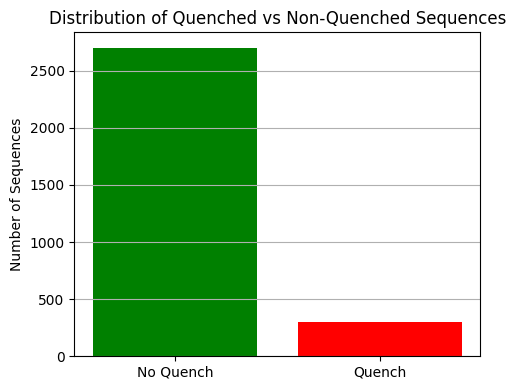

In [ ]:
#Esempio message passing da update_all
#define the embedding model
def build_layers_node(inputsize,outputsize,features,add_batch_norm=False,add_activation=None):
    layers = []
    layers.append(nn.Linear(inputsize,features[0]))
    layers.append(nn.ReLU())
    for hidden_i in range(1,len(features)):
        if add_batch_norm:
            layers.append(nn.BatchNorm1d(features[hidden_i-1]))
        layers.append(nn.Linear(features[hidden_i-1],features[hidden_i]))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(features[-1],outputsize))
    if add_activation!=None:
        layers.append(add_activation)
    return nn.Sequential(*layers)

#this is what is deciding the aggregration function of the message passing
class NodeNetwork(nn.Module):
    def __init__(self,inputsize,outputsize,layers):
        super().__init__()

        self.net = build_layers_node(2*inputsize,outputsize,layers) #note the factor 2

    def forward(self, x):

        #this takes the message that is being sent
        inputs = torch.sum( x.mailbox['message'] ,dim=1)
        inputs = torch.cat([inputs,x.data['hidden rep']],dim=1)
        #MLP that takes as input the hidden representation  and updates it at the node level
        output = self.net(inputs)
        output = output / torch.norm(output, p='fro', dim=1, keepdim=True)

        return {'hidden rep': output }


In [ ]:
g.update_all(fn.copy_u('hidden rep','message'), self.node_update_networks)


torch.Size([32, 24, 15, 15])
torch.Size([32, 1])
